0.7768729641693811
0.7597402597402597
|--- feature_1 <= 127.50
|   |--- feature_7 <= 28.50
|   |   |--- feature_5 <= 30.95
|   |   |   |--- class: 0
|   |   |--- feature_5 >  30.95
|   |   |   |--- class: 0
|   |--- feature_7 >  28.50
|   |   |--- feature_5 <= 26.35
|   |   |   |--- class: 0
|   |   |--- feature_5 >  26.35
|   |   |   |--- class: 0
|--- feature_1 >  127.50
|   |--- feature_5 <= 29.95
|   |   |--- feature_1 <= 146.50
|   |   |   |--- class: 0
|   |   |--- feature_1 >  146.50
|   |   |   |--- class: 1
|   |--- feature_5 >  29.95
|   |   |--- feature_1 <= 165.50
|   |   |   |--- class: 1
|   |   |--- feature_1 >  165.50
|   |   |   |--- class: 1

[[83 16]
 [21 34]]
Accuracy: 0.7597402597402597
Precision: 0.68
Recall: 0.6181818181818182
f1 score: 0.6476190476190476


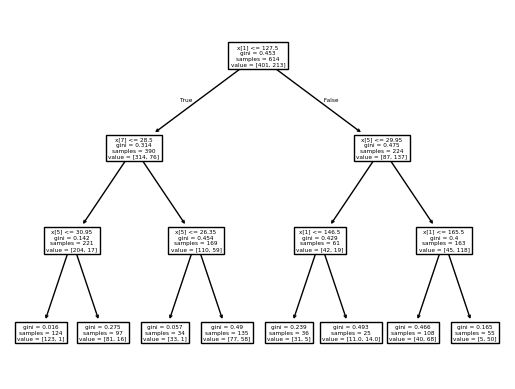

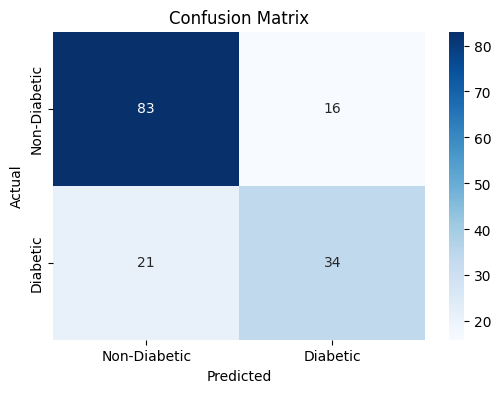

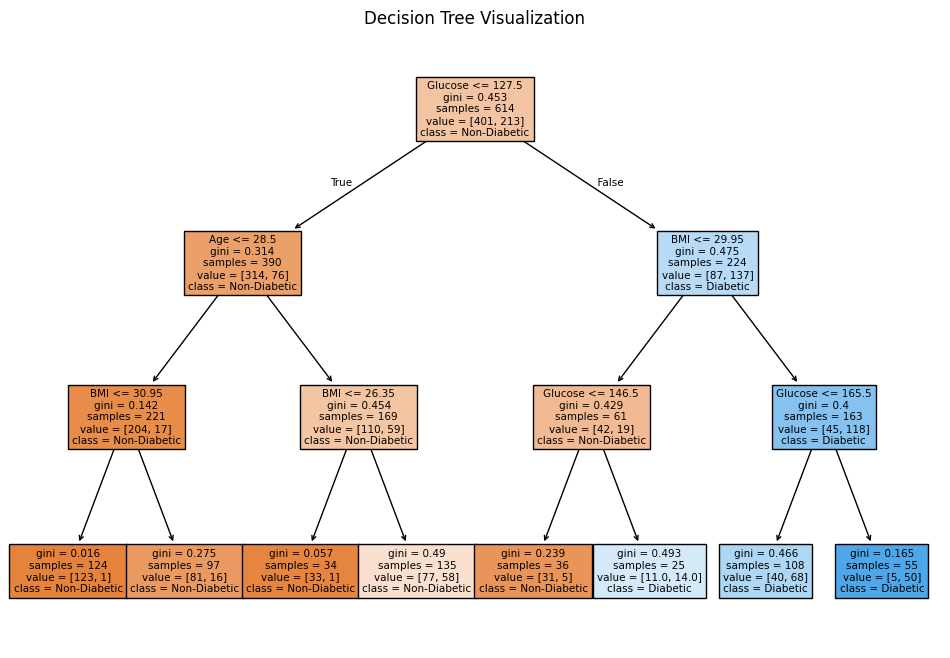


Best Parameters from Grid Search: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path='/content/Diabetes dataset.csv'
data=pd.read_csv(path)
data.head()

X=data[['Pregnancies','Glucose',	'BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']].values
Y=data['Outcome'].values

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
#print(x_train)
#print(x_test)

from sklearn.tree import DecisionTreeClassifier,export_text,plot_tree
from sklearn.datasets import load_diabetes
clf=DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=0)
clf.fit(x_train,y_train)
print(clf.score(x_train,y_train))
print(clf.score(x_test,y_test))
print(export_text(clf))
plot_tree(clf)
y_pred = clf.predict(x_test)

from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test,y_pred)
print(cnf_matrix)

print("Accuracy:",metrics.accuracy_score(y_test,y_pred))
print("Precision:",metrics.precision_score(y_test,y_pred))
print("Recall:",metrics.recall_score(y_test,y_pred))
print("f1 score:",metrics.f1_score(y_test,y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(cnf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Diabetic', 'Diabetic'], yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12, 8))
# Assuming 'diabetes_features' contains the original feature names:
diabetes_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
plot_tree(clf, feature_names=diabetes_features, class_names=['Non-Diabetic', 'Diabetic'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

from sklearn.model_selection import GridSearchCV
param_grid={
    'max_depth': [3, 4, 5, 6],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)
best_model = grid_search.best_estimator_
print("\nBest Parameters from Grid Search:", grid_search.best_params_)
y_pred_best = best_model.predict(x_test)
#accuracy_best =accuracy_score(y_test, y_pred_best)
#print(f"\nRe-evaluated Accuracy with Best Parameters: {accuracy_best:.2f}")